### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Agrupando en lista las Tiendas.
tiendas = [tienda1, tienda2, tienda3, tienda4]

# Calcular la suma total de facturado por tienda.
facturacion = [] # Inicializar una lista vacía para almacenar la facturación
for i, df in enumerate(tiendas):
    suma_total = df['Precio'].sum()
    facturacion.append(suma_total) # Agregar la facturación a la lista

    # Imprimiendo los resultados.
    print(f"En la Tienda {i+1}, la facturación total es de: ${suma_total:,.0f}.")

En la Tienda 1, la facturación total es de: $1,150,880,400.
En la Tienda 2, la facturación total es de: $1,116,343,500.
En la Tienda 3, la facturación total es de: $1,098,019,600.
En la Tienda 4, la facturación total es de: $1,038,375,700.


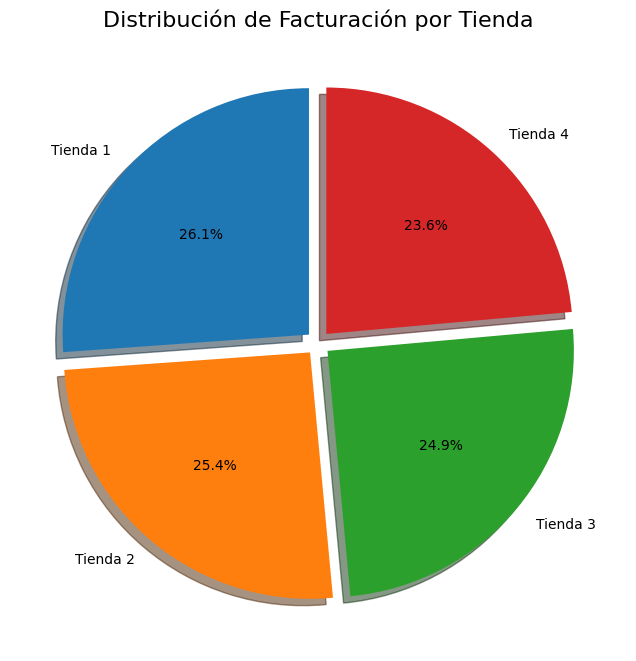

In [3]:
import matplotlib.pyplot as plt
# Gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(facturacion, labels=[f'Tienda {i+1}' for i in range(len(tiendas))], autopct='%1.1f%%',
        colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
        startangle=90, shadow=True, explode=(0.05, 0.05, 0.05, 0.05))
plt.title('Distribución de Facturación por Tienda', fontsize=16)
plt.show()

# 2. Ventas por categoría

In [4]:
# Lista para almacenar los resultados (categoría más frecuente y su conteo).
resultados = []

# Iteración sobre cada tienda
for tienda_df in tiendas:
  # Contar categorías
  conteo_categorias = tienda_df['Categoría del Producto'].value_counts()
  # Obtener la categoría con mayor conteo
  max_categoria = conteo_categorias.idxmax()
  # Obtener el conteo máximo
  max_valor = conteo_categorias.max()
  # Agregar resultados a la lista
  resultados.append((max_categoria, max_valor))

# Imprimir los resultados.
for i, (categoria, valor) in enumerate(resultados):
  print(f"En la Tienda {i+1}, la Categoría más común es: {categoria}, con un Conteo de: {valor}.")

En la Tienda 1, la Categoría más común es: Muebles, con un Conteo de: 465.
En la Tienda 2, la Categoría más común es: Muebles, con un Conteo de: 442.
En la Tienda 3, la Categoría más común es: Muebles, con un Conteo de: 499.
En la Tienda 4, la Categoría más común es: Muebles, con un Conteo de: 480.


# 3. Calificación promedio de la tienda


In [5]:
# Calcular la suma total de calificaciones y el total de calificaciones por tienda.
promedio_tienda = []
for i, df in enumerate(tiendas):
    suma_total = df['Calificación'].sum()
    calificadas = len(df)
    promedio = suma_total / calificadas
    promedio_tienda.append(promedio)
    # Imprimiendo los resultados.
    print(f"En la Tienda {i+1}, el Promedio de calificación es: {promedio:.2f}.")

En la Tienda 1, el Promedio de calificación es: 3.98.
En la Tienda 2, el Promedio de calificación es: 4.04.
En la Tienda 3, el Promedio de calificación es: 4.05.
En la Tienda 4, el Promedio de calificación es: 4.00.


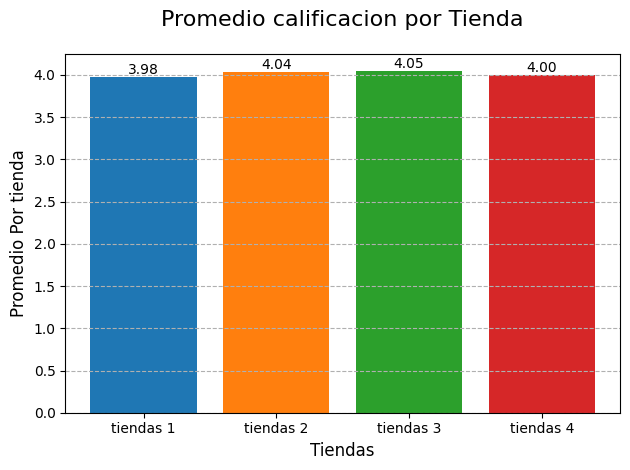

In [6]:
import matplotlib.pyplot as plt
# Gráfico de barras
# Use a list of strings or numbers as the x values
bars = plt.bar([f'tiendas {i+1}' for i in range(len(tiendas))], promedio_tienda, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Añadir los valores en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# Personalización del gráfico
plt.title('Promedio calificacion por Tienda', fontsize=16, pad=20)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Promedio Por tienda', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=1)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [7]:
for i, tienda_df in enumerate(tiendas, start=1):
    # Contar frecuencia de cada producto (número de veces que aparece)
    conteo_producto = tienda_df['Producto'].value_counts()

    # Obtener producto más vendido (mayor frecuencia)
    producto_mas_vendido = conteo_producto.idxmax()
    cantidad_mas_vendido = conteo_producto.max()

    # Obtener producto menos vendido (menor frecuencia)
    producto_menos_vendido = conteo_producto.idxmin()
    cantidad_menos_vendido = conteo_producto.min()

    print(f"\nTienda {i}:")
    print("--------------------------------")
    print(f"Producto más vendido: {producto_mas_vendido} con {cantidad_mas_vendido} Veces en ventas.")
    print(f"Producto menos vendido: {producto_menos_vendido} con {cantidad_menos_vendido} Veces en ventas.")

    # Almacenar resultados
    resultados.append({
        'Tienda': f'Tienda {i}',
        'Producto_mas_vendido': producto_mas_vendido,
        'Cantidad_mas_vendido': cantidad_mas_vendido,
        'Producto_menos_vendido': producto_menos_vendido,
        'Cantidad_menos_vendido': cantidad_menos_vendido
    })


Tienda 1:
--------------------------------
Producto más vendido: Microondas con 60 Veces en ventas.
Producto menos vendido: Auriculares con micrófono con 33 Veces en ventas.

Tienda 2:
--------------------------------
Producto más vendido: Iniciando en programación con 65 Veces en ventas.
Producto menos vendido: Juego de mesa con 32 Veces en ventas.

Tienda 3:
--------------------------------
Producto más vendido: Kit de bancas con 57 Veces en ventas.
Producto menos vendido: Bloques de construcción con 35 Veces en ventas.

Tienda 4:
--------------------------------
Producto más vendido: Cama box con 62 Veces en ventas.
Producto menos vendido: Guitarra eléctrica con 33 Veces en ventas.


# 5. Envío promedio por tienda

In [8]:
promedio_envio = []
for i, df in enumerate(tiendas):
    # Filtrando los valores en 0
    df_filtrado = df.where(df['Costo de envío'] != 0)
    suma_total = df_filtrado['Costo de envío'].sum()
    # Si la suma es NaN, se calcula el promedio como 0

    if pd.isna(suma_total):
        promedio = 0
    else:
        total_envios = len(df_filtrado.dropna())
        promedio = suma_total / total_envios
        promedio_envio.append(promedio)
    # Imprimiendo los resultados.
    print(f"En la Tienda {i+1}, el Promedio de envio es de: ${promedio:,.0f}.")
    print("--------------------------------")

En la Tienda 1, el Promedio de envio es de: $28,548.
--------------------------------
En la Tienda 2, el Promedio de envio es de: $27,732.
--------------------------------
En la Tienda 3, el Promedio de envio es de: $27,204.
--------------------------------
En la Tienda 4, el Promedio de envio es de: $25,586.
--------------------------------


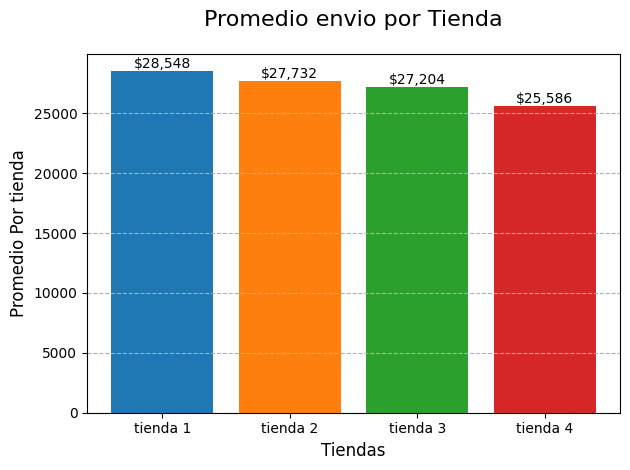

In [9]:
import matplotlib.pyplot as plt
# Gráfico de barras
# Use a list of strings or numbers as the x values
bars = plt.bar([f'tienda {i+1}' for i in range(len(tiendas))], promedio_envio, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Añadir los valores en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom')

# Personalización del gráfico
plt.title('Promedio envio por Tienda', fontsize=16, pad=20)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Promedio Por tienda', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=1)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
"""
El propósito de este análisis es ayudar al señor Juan a tomar una decisión importante acerca de vender una de sus cuatro tiendas "Alure Store".
Es por ello que desde el análisis de datos se desarrollan 5 actividades en las que se puede detectar la tienda menos productiva, la cual es la mas opcionada en realizar la venta.
En el desarrollo de este análisis se encuentra que la tienda con mayor ingreso es la "Tienda 1" como se puede apreciar en el punto 1,
en donde la facturación de esta supera a las demás tiendas, no por mucho dinero, pero si en una significativa ventaja, aportando asi el 26.1% de ingresos a "Alura Store",
es también de aclarar que dicha tienda en califición es la mas baja con 3.98 puntos de 5, por lo que sería beneficioso para la tienda mejorar en la atención al cliente,
a su vez mejorando la facturación y fortaleciendo la cadena de tiendas.
Para concluir, según analisis realizados se encuentra que la "tienda 4" no representa buena fuente de ingresos al ser la tienda con la facturacion mas baja,
y su promedio de calificación es el tercero mas bajo, es por esto que se recomienda la venta de esta tienda.
"""


'\nEl propósito de este análisis es ayudar al señor Juan a tomar una decisión importante acerca de vender una de sus cuatro tiendas "Alure Store".\nEs por ello que desde el análisis de datos se desarrollan 5 actividades en las que se puede detectar la tienda menos productiva, la cual es la mas opcionada en realizar la venta.\nEn el desarrollo de este análisis se encuentra que la tienda con mayor ingreso es la "Tienda 1" como se puede apreciar en el punto 1,\nen donde la facturación de esta supera a las demás tiendas, no por mucho dinero, pero si en una significativa ventaja, aportando asi el 26.1% de ingresos a "Alura Store",\nes también de aclarar que dicha tienda en califición es la mas baja con 3.98 puntos de 5, por lo que sería beneficioso para la tienda mejorar en la atención al cliente, \na su vez mejorando la facturación y fortaleciendo la cadena de tiendas.\nPara concluir, según analisis realizados se encuentra que la "tienda 4" no representa buena fuente de ingresos al ser la 